In [19]:
%pip install kagglehub

# Import libraries
import kagglehub
import os
import shutil
import pandas as pd

# Download Kaggle Data
path = kagglehub.dataset_download("shivamb/netflix-shows")

# Add to Sidebar
shutil.copy(os.path.join(path, 'netflix_titles.csv'), './netflix_titles.csv')

# Load it into your table (DataFrame)
df = pd.read_csv('netflix_titles.csv')


Note: you may need to restart the kernel to use updated packages.


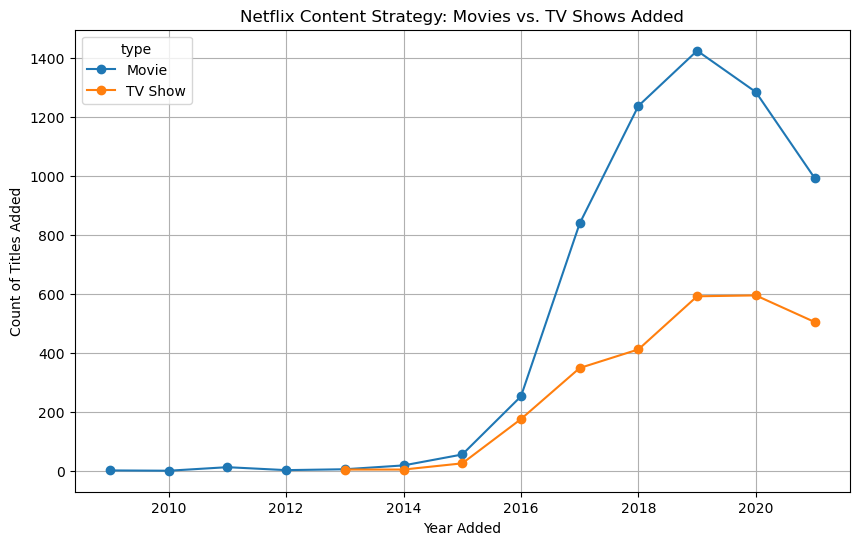

In [21]:
# A: Analyze the year-over-year growth rate of TV Shows

import matplotlib.pyplot as plt

# Clean the data (Converting to string first prevents the AttributeError)
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip())
df['year_added'] = df['date_added'].dt.year

# Drop missing values and format the year
df = df.dropna(subset=['year_added'])
df['year_added'] = df['year_added'].astype(int)

# Group the content by year and type (Movie vs TV Show)
content_by_year = df[df['year_added'] > 2008].groupby(['year_added', 'type']).size().unstack()

# Plot the results to see the strategic pivot
content_by_year.plot(kind='line', figsize=(10, 6), marker='o')
plt.title('Netflix Content Strategy: Movies vs. TV Shows Added')
plt.ylabel('Count of Titles Added')
plt.xlabel('Year Added')
plt.grid(True)
plt.show()

Pivot: Netflix successfully pivoted to a TV-first strategy starting in 2016 to drive recurring user sessions.

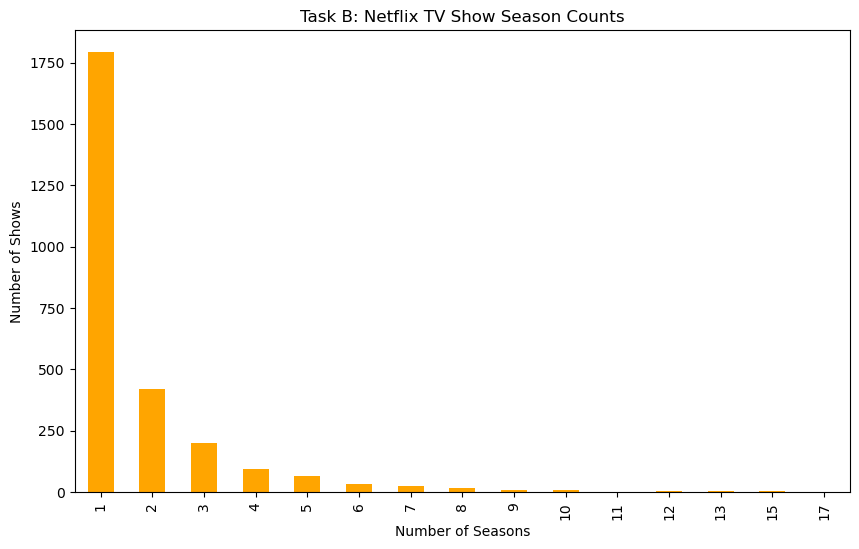

season_count
1    1793
2     421
3     198
4      94
5      64
Name: count, dtype: int64


In [23]:
# B: TV Show Longevity Code

import matplotlib.pyplot as plt

# Filter for Tv Shows
tv_df = df[df['type'] == 'TV Show'].copy()

# Extract the Number of Seasons
tv_df['season_count'] = tv_df['duration'].str.extract('(\d+)').astype(int)

# Create Bar Graph
tv_df['season_count'].value_counts().sort_index().plot(kind='bar', color='orange', figsize=(10, 6))
plt.title('Task B: Netflix TV Show Season Counts')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of Shows')
plt.show()

# Raw Numbers 
print(tv_df['season_count'].value_counts().sort_index().head(5))


Sustainability: The "One-Season Cliff" shows that over 60% of series fail to gain enough traction for a second season.

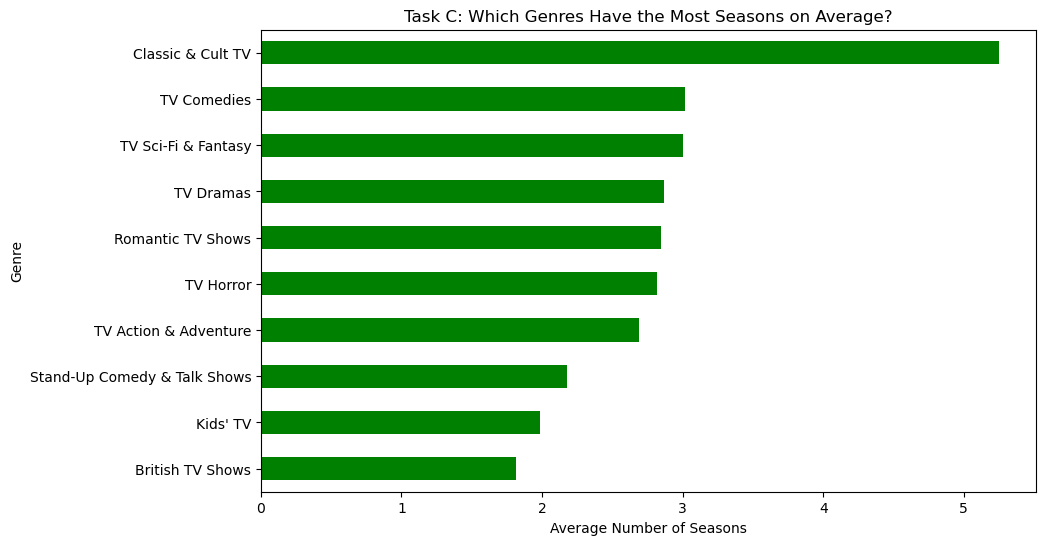

--- Top 5 Genres by Longevity ---
main_genre
Classic & Cult TV      5.250000
TV Comedies            3.016807
TV Sci-Fi & Fantasy    3.000000
TV Dramas              2.865672
Romantic TV Shows      2.843750
Name: season_count, dtype: float64


In [25]:
# Task C: Genre Efficiency

import matplotlib.pyplot as plt

# Simplify the genres
tv_df['main_genre'] = tv_df['listed_in'].str.split(',').str[0]

# Group by genre and calculate the average seasons
genre_longevity = tv_df.groupby('main_genre')['season_count'].mean().sort_values(ascending=False)

# Plot the top 10 genres to see what has retention
genre_longevity.head(10).plot(kind='barh', color='green', figsize=(10, 6))

# Add Titles
plt.title('Task C: Which Genres Have the Most Seasons on Average?')
plt.xlabel('Average Number of Seasons')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.show()

# Raw list
print("--- Top 5 Genres by Longevity ---")
print(genre_longevity.head(5))

Genre ROI: "Classic & Cult TV" is the only genre consistently reaching 5+ seasons, making it the most stable investment.

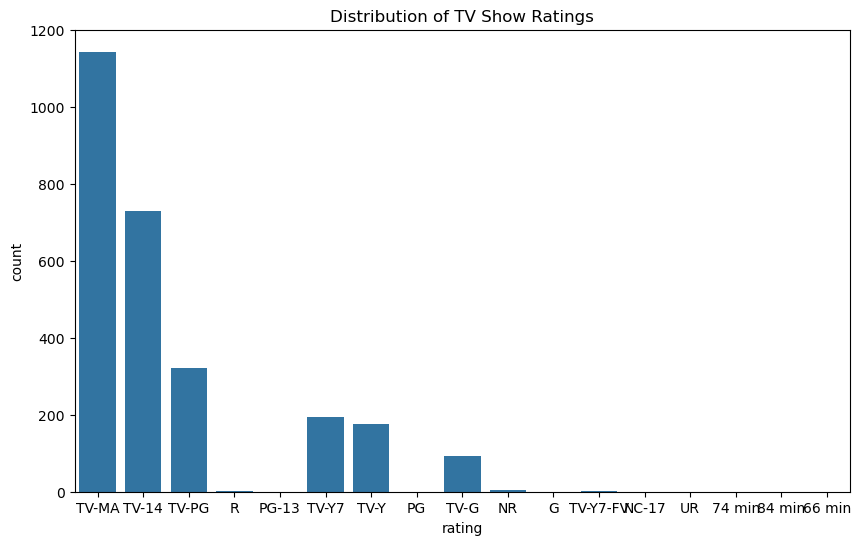

In [29]:
# D Target audience demographic
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.countplot(data=df[df['type'] == 'TV Show'], x='rating', order=df['rating'].value_counts().index)
plt.title('Distribution of TV Show Ratings')
plt.show()

Ratings: With TV-MA dominating the library, content acquisition must remain focused on mature, adult audiences.

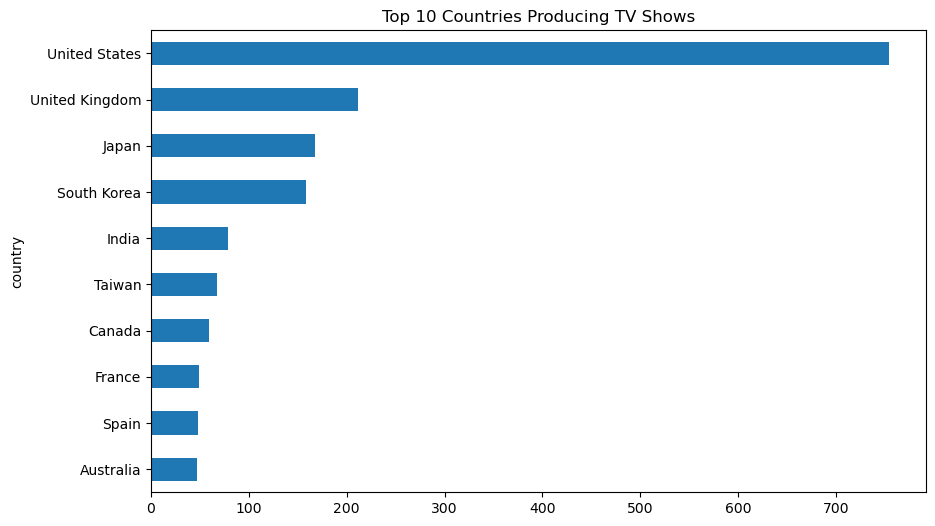

In [27]:
# E Identifying the primary hubs for series production
top_10_countries = df[df['type'] == 'TV Show']['country'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_10_countries.plot(kind='barh').invert_yaxis()
plt.title('Top 10 Countries Producing TV Shows')
plt.show()


Global Hubs: While US-centric, Hubs like the UK and India are the primary engines for international series expansion.

A2: The Synthesis of Data (Updated for 5 Visuals)
This goes into a Markdown cell at the bottom of your Python notebook and a Text Box on your Tableau dashboard.

Strategy Shift: The line graph proves Netflix moved to a "TV-first" strategy in 2016 to prioritize recurring engagement.

The Sustainability Gap: The season distribution shows a high "burn rate," with over 60% of shows failing to survive past Season 1.

The Solution: "Classic" and "Cult" TV are the outliers that break the 1-season curse, averaging 5+ seasons.

Audience Fit: The Ratings data confirms the TV library is built for a mature (TV-MA) demographic, matching the profile of "Cult" IP.

Growth Hubs: The US, UK, and India are the primary production engines where this sustainable content should be sourced.